--- 1. Loading Adult Income Dataset ---
Training shape: (39073, 14)
Target distribution:
class
0    76.072992
1    23.927008
Name: proportion, dtype: float64

--- 2. Handling Outliers (TP8.3) ---
Applied log1p transformation to 'capital-gain' to compress extreme outliers.

--- 3. Building Preprocessing Pipelines (TP8.2) ---

--- 4. Training Models on Imbalanced Data (TP8.4) ---
Training Logistic Regression...
Training XGBoost...

--- 5. Evaluation ---

Model: Logistic Regression (Balanced)
F1-Score: 0.6692
ROC-AUC:  0.8992


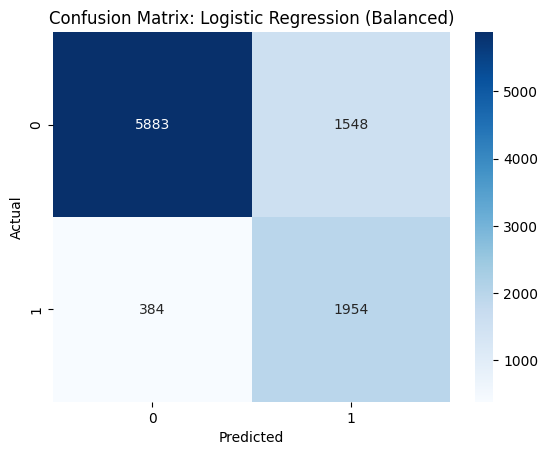


Model: XGBoost (Scaled Pos Weight)
F1-Score: 0.7132
ROC-AUC:  0.9295


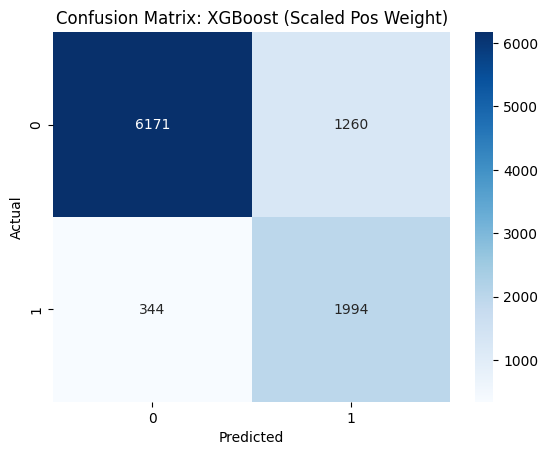

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Load Data & Initial Setup (TP8 Intro)
# ==========================================
print("--- 1. Loading Adult Income Dataset ---")
# Fetch dataset
adult = fetch_openml(name="adult", version=2, as_frame=True)
X = adult.data
y = adult.target

# Convert target to binary (1 for >50K, 0 for <=50K)
y = (y == '>50K').astype(int)

# Stratified split to maintain the class imbalance ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training shape: {X_train.shape}")
print(f"Target distribution:\n{y_train.value_counts(normalize=True) * 100}")

# ==========================================
# 2. Outlier Detection & Handling (TP8.3)
# ==========================================
print("\n--- 2. Handling Outliers (TP8.3) ---")
# The 'capital-gain' feature has massive outliers. We will apply a Log Transformation
# Note: We apply this to both Train and Test to keep data consistent!
X_train['capital-gain'] = np.log1p(X_train['capital-gain'])
X_test['capital-gain'] = np.log1p(X_test['capital-gain'])

print("Applied log1p transformation to 'capital-gain' to compress extreme outliers.")

# ==========================================
# 3. Scaling and Encoding Pipelines (TP8.2)
# ==========================================
print("\n--- 3. Building Preprocessing Pipelines (TP8.2) ---")

# Identify numeric and categorical columns
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Preprocessing for numeric data: Standardize (mean=0, variance=1)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data: One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# ==========================================
# 4. Imbalanced Classification (TP8.4)
# ==========================================
print("\n--- 4. Training Models on Imbalanced Data (TP8.4) ---")

# Calculate the scale_pos_weight for XGBoost (Ratio of negative class to positive class)
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_weight = neg_class_count / pos_class_count

# Model 1: Logistic Regression with class weights
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Model 2: XGBoost with scale_pos_weight
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=scale_weight, random_state=42, eval_metric='logloss'))
])

# Train models
print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)

print("Training XGBoost...")
xgb_pipeline.fit(X_train, y_train)

# ==========================================
# 5. Evaluation and Comparison
# ==========================================
print("\n--- 5. Evaluation ---")

def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\nModel: {name}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

evaluate_model(lr_pipeline, "Logistic Regression (Balanced)", X_test, y_test)
evaluate_model(xgb_pipeline, "XGBoost (Scaled Pos Weight)", X_test, y_test)